Step 1: Import All Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os



In [ ]:
# Set visual style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Step 1: Advanced libraries for EDA and ML loaded.")

Step 1: Advanced libraries for EDA and ML loaded.


Loading of Dataset

In [ ]:
# Load dataset
df = pd.read_csv('Student_Performance_Dataset.csv')

Basic Dataset Overview

In [ ]:
df.head

<bound method NDFrame.head of    Division/Section   Unique id      Rollno       Student Name  \
0          SectionA  2401010005  2401010005              Aryan   
1          SectionA  2401010009  2401010009    Gaurav Upadhyay   
2          SectionA  2401010010  2401010010     Vanshika Dixit   
3          SectionA  2401010012  2401010012        Lucky Kumar   
4          SectionA  2401010020  2401010020        Sneha Gupta   
5          SectionA  2401010021  2401010021    Anshika Kashyap   
6          SectionA  2401010023  2401010023    Aditya Wadhawan   
7          SectionA  2401010025  2401010025        Nakul Arora   
8          SectionA  2401010029  2401010029  Kushagra Bhardwaj   
9          SectionA  2401010030  2401010030      Aditya Bhatia   
10         SectionA  2401010032  2401010032        Jony Gautam   
11         SectionA  2401010034  2401010034        Pranav Garg   
12         SectionA  2401010040  2401010040        Aadya Diwan   
13         SectionA  2401010053  2401010053   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 90 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Division/Section                                              50 non-null     object 
 1   Unique id                                                     50 non-null     int64  
 2   Rollno                                                        50 non-null     int64  
 3   Student Name                                                  50 non-null     object 
 4   VERBAL ABILITY_D (PP)                                         50 non-null     int64  
 5   VERBAL ABILITY_A (PP)                                         50 non-null     int64  
 6   VERBAL ABILITY_% (PP)                                         50 non-null     float64
 7   COMMUNITY SERVICES_D (PP)                                     50 non-null

In [ ]:
df.describe()

,Unique id,Rollno,VERBAL ABILITY_D (PP),VERBAL ABILITY_A (PP),VERBAL ABILITY_% (PP),COMMUNITY SERVICES_D (PP),COMMUNITY SERVICES_A (PP),COMMUNITY SERVICES_% (PP),Competitive Coding-I_D (PP),Competitive Coding-I_A (PP),...,Cosmetology_D (PP),Cosmetology_A (PP),Cosmetology_% (PP),Practical Robotics and UAV Applications_D (PP),Practical Robotics and UAV Applications_A (PP),Practical Robotics and UAV Applications_% (PP),Total_D,Total_A,Total_%,Predicted_GPA
count,5.000000e+01,5.000000e+01,50.0,50.000000,50.000000,50.0,50.0,50.0,50.0,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2.401010e+09,2.401010e+09,38.0,27.400000,72.104400,0.0,0.0,0.0,46.0,35.140000,...,0.780000,0.720000,1.846200,0.140000,0.120000,1.714200,353.820000,286.020000,80.855200,3.929800
std,5.826870e+01,5.826870e+01,0.0,4.130524,10.870649,0.0,0.0,0.0,0.0,5.111052,...,5.515433,5.091169,13.054605,0.989949,0.848528,12.121224,14.688174,29.333752,7.718008,0.587157
min,2.401010e+09,2.401010e+09,38.0,20.000000,52.630000,0.0,0.0,0.0,46.0,24.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,318.000000,230.000000,64.070000,2.250000
25%,2.401010e+09,2.401010e+09,38.0,24.000000,63.160000,0.0,0.0,0.0,46.0,31.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,354.000000,268.000000,75.950000,3.602500
50%,2.401010e+09,2.401010e+09,38.0,28.000000,73.680000,0.0,0.0,0.0,46.0,36.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,361.000000,284.500000,81.445000,3.935000
75%,2.401010e+09,2.401010e+09,38.0,30.000000,78.950000,0.0,0.0,0.0,46.0,38.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,361.000000,312.000000,86.475000,4.317500
max,2.401010e+09,2.401010e+09,38.0,36.000000,94.740000,0.0,0.0,0.0,46.0,46.000000,...,39.000000,36.000000,92.310000,7.000000,6.000000,85.710000,370.000000,359.000000,98.900000,5.100000


In [ ]:
df.columns

Index(['Division/Section', 'Unique id', 'Rollno', 'Student Name',
       'VERBAL ABILITY_D (PP)', 'VERBAL ABILITY_A (PP)',
       'VERBAL ABILITY_% (PP)', 'COMMUNITY SERVICES_D (PP)',
       'COMMUNITY SERVICES_A (PP)', 'COMMUNITY SERVICES_% (PP)',
       'Competitive Coding-I_D (PP)', 'Competitive Coding-I_A (PP)',
       'Competitive Coding-I_% (PP)', 'JAVA PROGRAMMING_D (PP)',
       'JAVA PROGRAMMING_A (PP)', 'JAVA PROGRAMMING_% (PP)',
       'DISCRETE MATHEMATICS_D (PP)', 'DISCRETE MATHEMATICS_A (PP)',
       'DISCRETE MATHEMATICS_% (PP)', 'DATA STRUCTURES_D (PP)',
       'DATA STRUCTURES_A (PP)', 'DATA STRUCTURES_% (PP)',
       'FUNDAMENTALS OF AI & MACHINE LEARNING_D (PP)',
       'FUNDAMENTALS OF AI & MACHINE LEARNING_A (PP)',
       'FUNDAMENTALS OF AI & MACHINE LEARNING_% (PP)',
       'JAVA PROGRAMMING LAB_D (PR)', 'JAVA PROGRAMMING LAB_A (PR)',
       'JAVA PROGRAMMING LAB_% (PR)', 'DATA STRUCTURES LAB_D (PR)',
       'DATA STRUCTURES LAB_A (PR)', 'DATA STRUCTURES LAB_% (P

In [ ]:
print(f"\nMissing Values:\n{df.isnull().sum().sum()}")


Missing Values:
0


Step 3: Exploratory Data Analysis (EDA) & Visualization

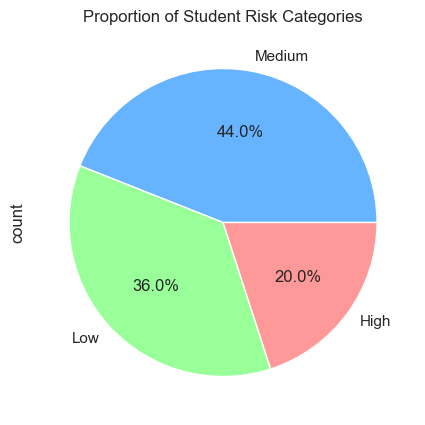

In [ ]:


def run_full_eda(df):
    
    # 1. Class Balance Check
    plt.figure(figsize=(7, 5))
    df['Risk_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
    plt.title('Proportion of Student Risk Categories')
    plt.show()

    

run_full_eda(df)

C:\Users\ddaga\AppData\Local\Temp\ipykernel_26108\671460935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df, palette='magma', order=['Low', 'Medium', 'High'])


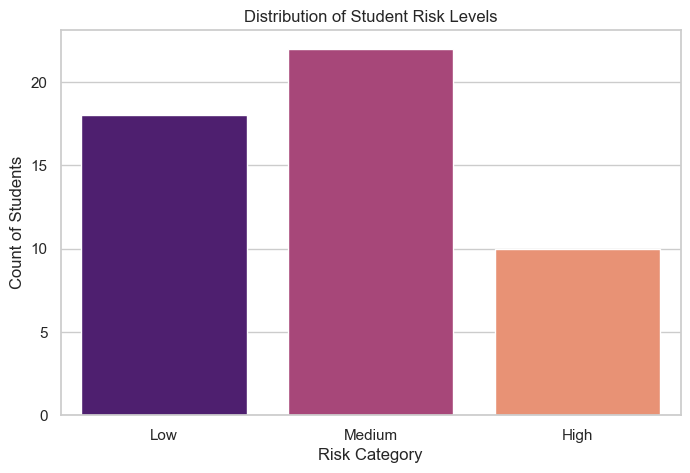

In [ ]:
# 2. Distribution of Risk Levels (Target Variable)
plt.figure(figsize=(8, 5))
sns.countplot(x='Risk_Level', data=df, palette='magma', order=['Low', 'Medium', 'High'])
plt.title('Distribution of Student Risk Levels')
plt.xlabel('Risk Category')
plt.ylabel('Count of Students')
plt.show()

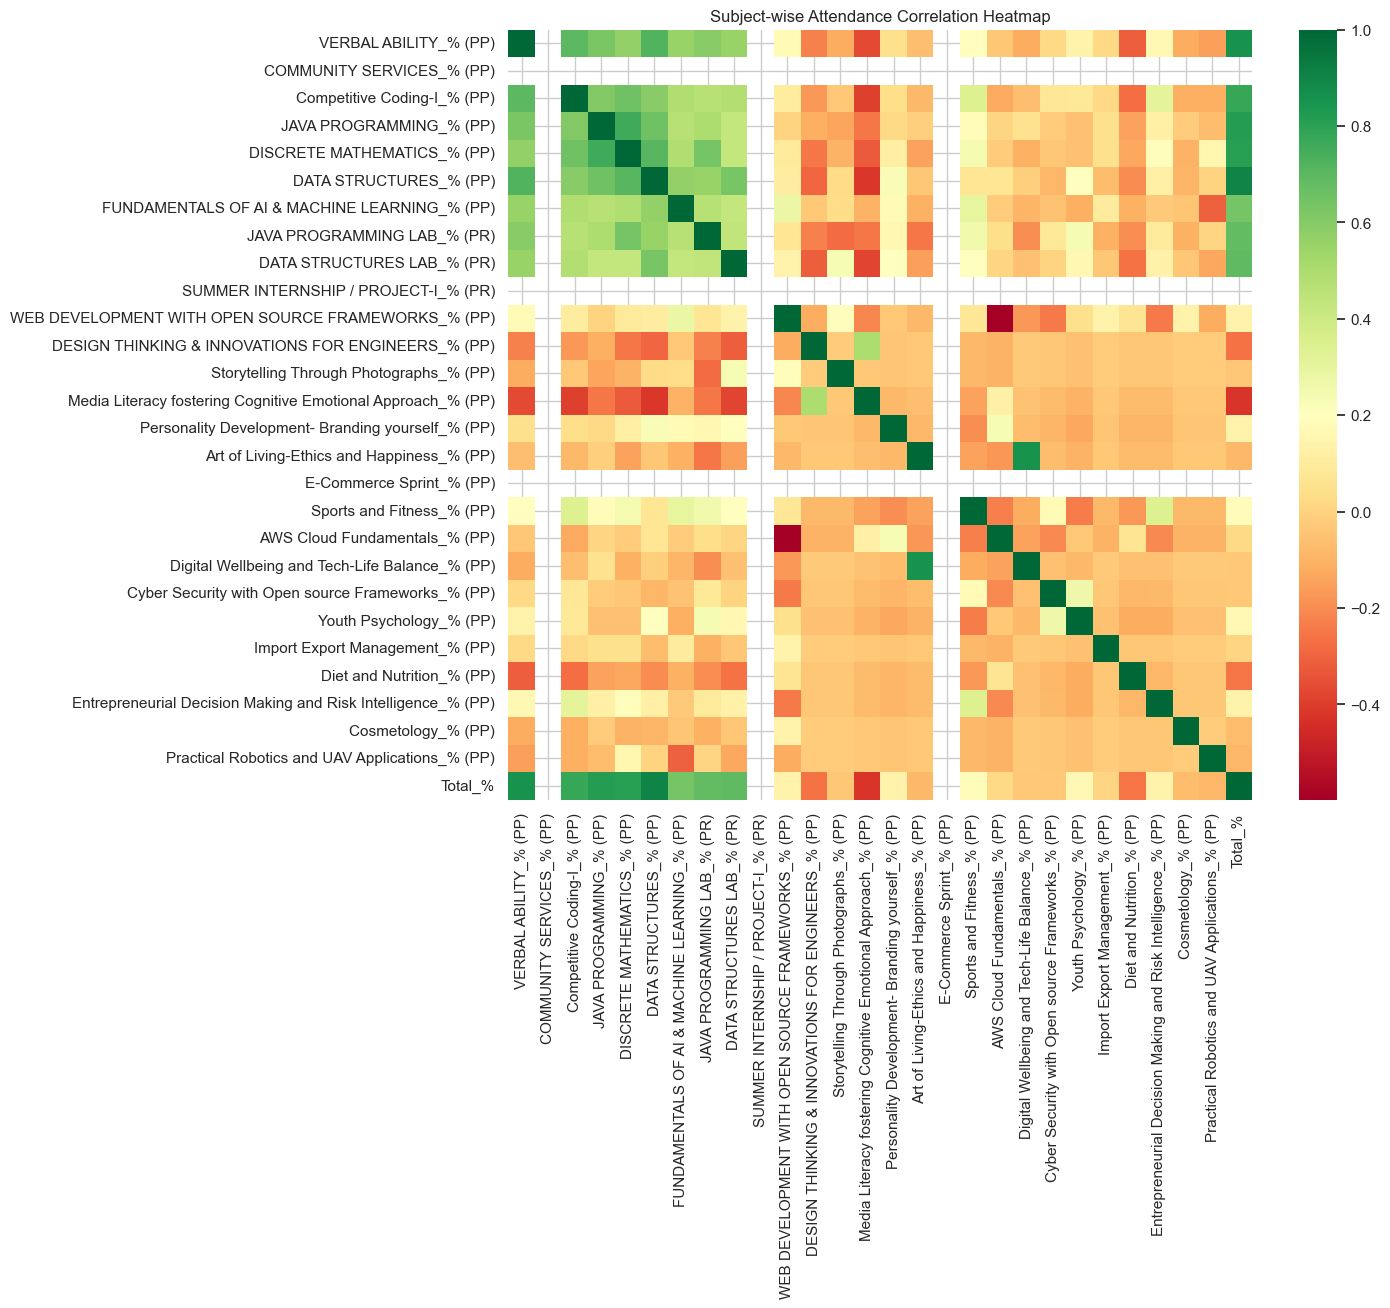

In [ ]:
# 3. Correlation Heatmap
# Selecting only numerical attendance columns for the heatmap
numeric_cols = [col for col in df.columns if '%' in col]
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='RdYlGn')
plt.title('Subject-wise Attendance Correlation Heatmap')
plt.show()

C:\Users\ddaga\AppData\Local\Temp\ipykernel_26108\3176341328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y='Total_%', data=df, palette='Set2')


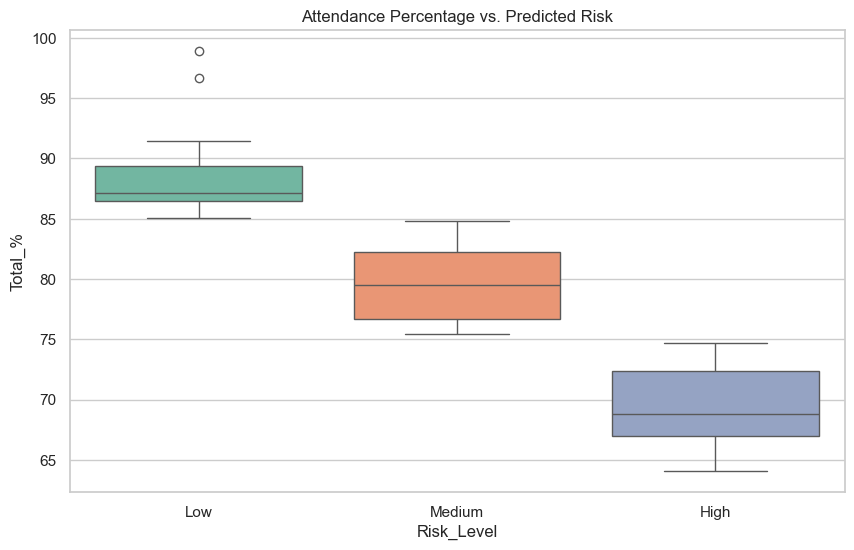

In [ ]:
# 4. Attendance vs Risk Level Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Risk_Level', y='Total_%', data=df, palette='Set2')
plt.title('Attendance Percentage vs. Predicted Risk')
plt.show()

Step 4: Feature Selection & Preprocessing

In [ ]:
# Select features: all subject percentage columns except the total
feature_cols = [col for col in df.columns if '%' in col and col != 'Total_%' and col != 'Risk_Level']

X = df[feature_cols]
y = df['Risk_Level']

In [ ]:
# Convert categorical labels to numeric for the model
# Low: 0, Medium: 1, High: 2
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_encoded = y.map(risk_map)

In [ ]:
# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"\nStep 4: Data split complete. Training on {len(X_train)} samples.")


Step 4: Data split complete. Training on 40 samples.


Step 5: Model Training (Random Forest)

In [ ]:
#Step 5.1: Initialize Multiple Models

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 'multi_class' parameter hata diya gaya hai, ye ab automatic hota hai
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM": SVC(probability=True, kernel='linear', class_weight='balanced')
}

print("✅ Step 5.1: Models initialized and ready for comparison.")

✅ Step 5.1: Models initialized and ready for comparison.


In [ ]:
#Step 5.2: Training and Accuracy Check

model_results = {}

print("--- Training Models ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    model_results[name] = acc
    print(f"✔️ {name} Accuracy: {acc*100:.2f}%")

print("\n✅ Step 5.2: Training loop finished.")

--- Training Models ---
✔️ Logistic Regression Accuracy: 60.00%
✔️ Random Forest Accuracy: 90.00%
✔️ SVM Accuracy: 60.00%

✅ Step 5.2: Training loop finished.


C:\Users\ddaga\AppData\Local\Temp\ipykernel_26108\4115571222.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, palette='viridis')


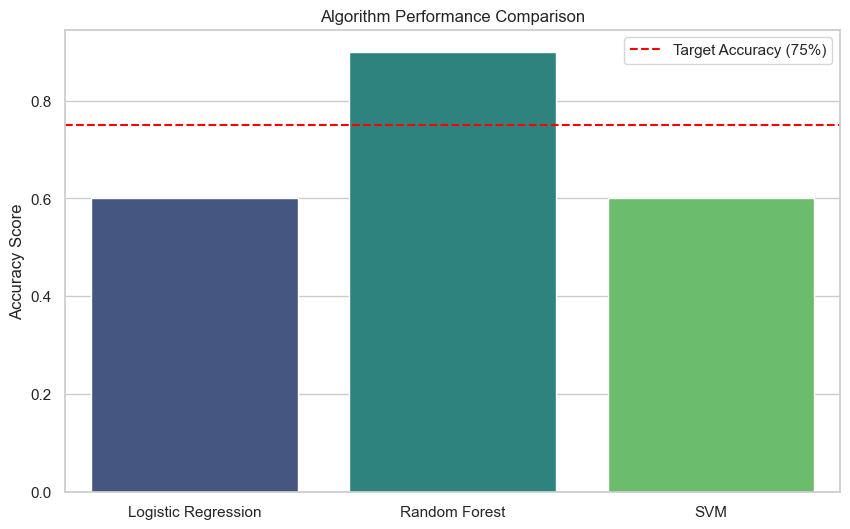

In [ ]:
# Step 5.3: Visual Comparison (Display Only)

plt.figure(figsize=(10, 6))
names = list(model_results.keys())
values = list(model_results.values())

sns.barplot(x=names, y=values, palette='viridis')
plt.axhline(0.75, color='red', linestyle='--', label='Target Accuracy (75%)') # Visual benchmark
plt.title('Algorithm Performance Comparison')
plt.ylabel('Accuracy Score')
plt.legend()

# ONLY show, do not save to folder
plt.show()

🏆 Best Performing Model: Random Forest


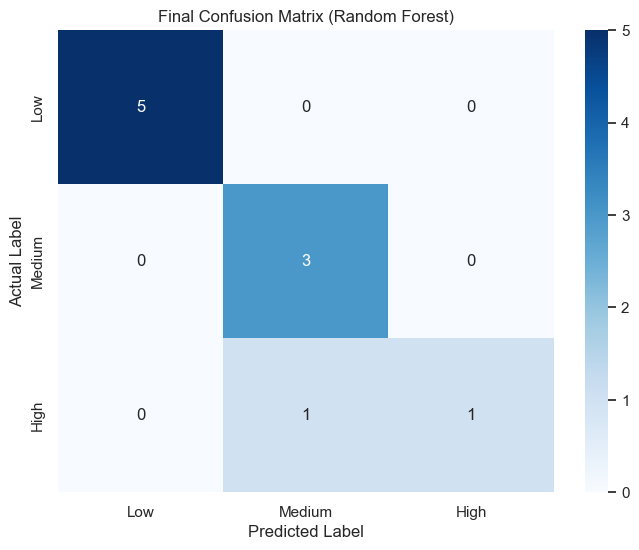

In [ ]:
# Step 5.4: Detailed Metrics for the Champion

# Select the winner
best_model_name = max(model_results, key=model_results.get)
best_model = models[best_model_name]

print(f"🏆 Best Performing Model: {best_model_name}")

# Show Confusion Matrix
y_pred_final = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title(f'Final Confusion Matrix ({best_model_name})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Show only
plt.show()

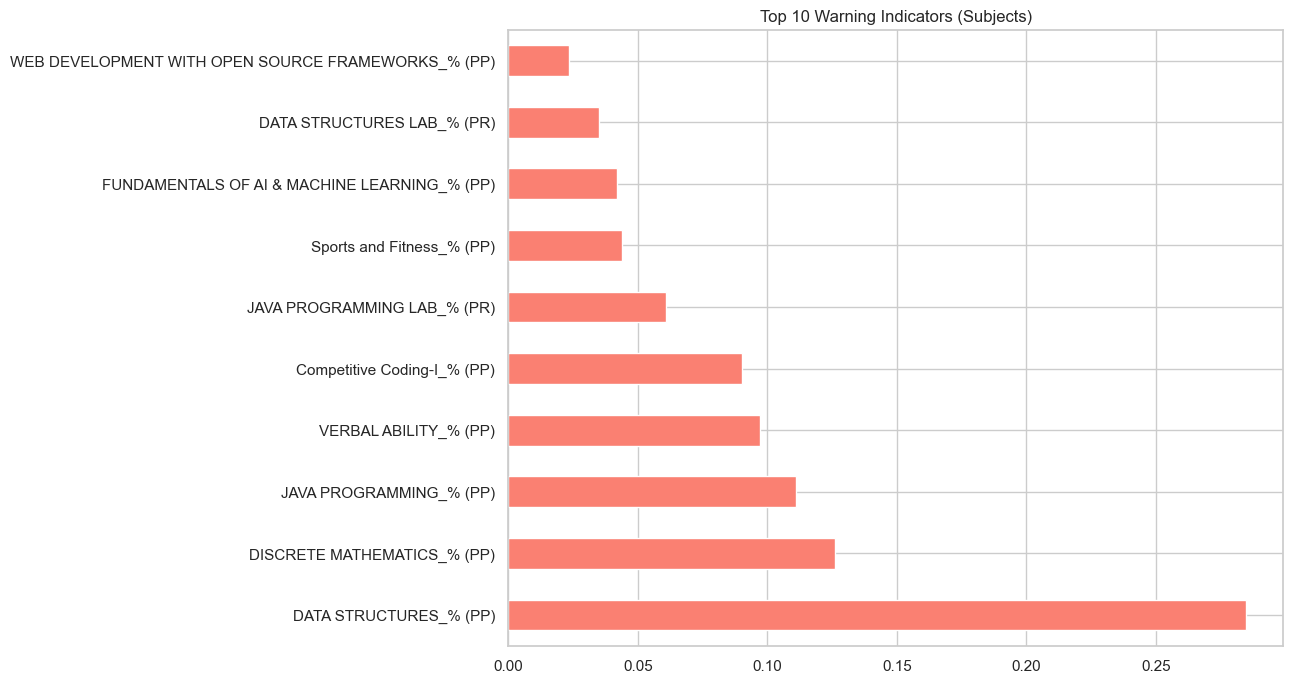

In [ ]:
# Step 5.5: Feature Importance

# This step works best with Random Forest
if best_model_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    plt.figure(figsize=(10, 8))
    importances.nlargest(10).plot(kind='barh', color='salmon')
    plt.title('Top 10 Warning Indicators (Subjects)')
    plt.show()
else:
    print(f"Feature importance is not directly visualized for {best_model_name} in this step.")

In [ ]:
# Step 5.6: Exporting the "Brain"

import os
import joblib

# Directory check
if not os.path.exists('models'):
    os.makedirs('models')

# Metadata preparation
metadata = {
    'features': feature_cols,
    'risk_mapping': {'Low': 0, 'Medium': 1, 'High': 2},
    'inverse_mapping': {0: 'Low', 1: 'Medium', 2: 'High'}
}

# Exporting with the correct variable name 'best_model'
try:
    joblib.dump(best_model, 'models/student_risk_model.pkl')
    joblib.dump(metadata, 'models/model_metadata.pkl')
    print("✅ Success: student_risk_model.pkl and metadata saved successfully!")
except NameError:
    print("❌ Error: 'best_model' not found. Make sure Step 5.4 finished successfully.")

✅ Success: student_risk_model.pkl and metadata saved successfully!


STEP 6: Automated Alert & Notification System

In [ ]:
def trigger_academic_alerts(student_name, risk_score):
    """Generates alerts based on predicted risk level"""
    if risk_score == 2: # High Risk
        return f"🚨 ALERT for {student_name}: High Risk! Sending notification to Parents & Mentor for urgent guidance."
    elif risk_score == 1: # Medium Risk
        return f"⚠️ WARNING for {student_name}: Performance is dipping. Notification sent to Mentor for proactive support."
    else:
        return f"✅ Status for {student_name}: Normal. Keep it up!"

# Example test on first 5 students of test set
test_indices = X_test.index[:5]
for idx in test_indices:
    name = df.loc[idx, 'Student Name']
    pred = best_model.predict(X_test.loc[[idx]])[0]
    print(trigger_academic_alerts(name, pred))

🚨 ALERT for Faiz Khan: High Risk! Sending notification to Parents & Mentor for urgent guidance.
✅ Status for Ishaan Parashar: Normal. Keep it up!
✅ Status for Khushi: Normal. Keep it up!
⚠️ WARNING for Yashieta Sethi: Performance is dipping. Notification sent to Mentor for proactive support.
⚠️ WARNING for Anjali: Performance is dipping. Notification sent to Mentor for proactive support.


STEP 7: Attendance Monitoring Logic

In [ ]:
# Step 7 ko aur realistic banane ke liye
def check_consecutive_absence_simulated(df):
    print("\n--- Running Daily Attendance Check (Simulation) ---")
    # Hum random sample le rahe hain dikhane ke liye
    for index, row in df.sample(5).iterrows():
        # Simulation: Maan lo pichle 3 din ka status 'absent' (0) hai
        # Real system mein ye data daily attendance table se aayega
        consecutive_absents = 3 
        
        if consecutive_absents >= 3:
            print(f"📱 PARENT NOTIFICATION: {row['Student Name']} (Roll: {row['Rollno']}) is absent since 3 days!")
            # Yahan real integration mein SMS API call hogi

STEP 8: Teacher Insight Dashboard Logic

In [ ]:
def get_teacher_guidance_insight(df, student_idx):
    student_data = df.iloc[student_idx]
    name = student_data['Student Name']
    
    # Mentor's Hint: Identify students who are good in Practical but low in Theory (Nervous)
    # Checking Java as an example from your dataset
    theory_marks = student_data['JAVA PROGRAMMING_% (PP)']
    practical_marks = student_data['JAVA PROGRAMMING LAB_% (PR)']
    
    insight = f"\n--- Teacher Guidance Profile: {name} ---"
    insight += f"\nRisk Status: {student_data['Risk_Level']}"
    
    # Logic for Nervous Student
    if practical_marks > 80 and theory_marks < 65:
        insight += f"\n💡 OBSERVATION: Student is excellent in Practicals ({practical_marks}%) but struggles in Theory ({theory_marks}%)."
        insight += f"\n📢 ACTION: Likely a 'Nervous' student. Mentor should provide confidence-building guidance."
    
    # General weak areas check
    weak_areas = [col.split('_')[0] for col in feature_cols if student_data[col] < 50]
    if weak_areas:
        insight += f"\n🚨 ACADEMIC ALERT: Focus needed in: {', '.join(set(weak_areas))}"
        
    return insight

# Example: Check for a specific student
print(get_teacher_guidance_insight(df, 3))


--- Teacher Guidance Profile: Lucky Kumar ---
Risk Status: High
🚨 ACADEMIC ALERT: Focus needed in: Diet and Nutrition, COMMUNITY SERVICES, AWS Cloud Fundamentals, Import Export Management, DESIGN THINKING & INNOVATIONS FOR ENGINEERS, Art of Living-Ethics and Happiness, Youth Psychology, Storytelling Through Photographs, E-Commerce Sprint, Digital Wellbeing and Tech-Life Balance, Media Literacy fostering Cognitive Emotional Approach, Personality Development- Branding yourself, Entrepreneurial Decision Making and Risk Intelligence, Cosmetology, WEB DEVELOPMENT WITH OPEN SOURCE FRAMEWORKS, Practical Robotics and UAV Applications, SUMMER INTERNSHIP / PROJECT-I


In [ ]:
import joblib
joblib.dump(model, 'student_model.pkl')

print("Success: student_model.pkl file create ho gayi hai!")

Success: student_model.pkl file create ho gayi hai!
